Examen 1


Nombre:Caballero Condori Franz Abdel

Ejercicio 1 
Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir 
100x100 px como se muestra en la imagen a continuación (toma encuenta la saturación de los colores)

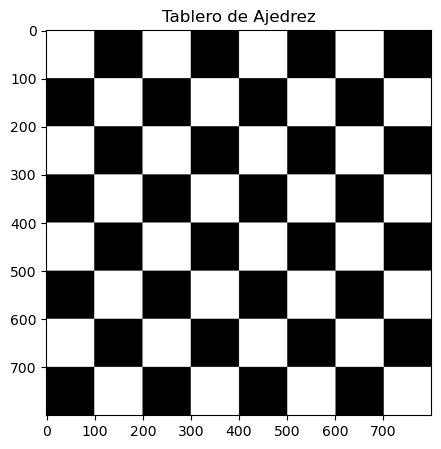

In [62]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
 
plt.rcParams['figure.figsize'] = [10, 5]
imgSize = 800 
square_size = 100 

chessboard = np.ones((imgSize, imgSize, 3), dtype=np.uint8) * 255

for i in range(0, imgSize, square_size):
  for j in range(0, imgSize, square_size):
    if (i // square_size + j // square_size) % 2 == 1:
      chessboard[i:i+square_size, j:j+square_size] = [0, 0, 0] 

plt.imshow(chessboard)
plt.title("Tablero de Ajedrez")
plt.show()



Ejercicio 2 : Genera una imagen como la de referencia.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

colores_wiphala = [
    [255, 255, 255],    # Blanco
    [255, 255, 0],  # Amarillo
    [255, 127, 0],  # Naranja
    [255, 0, 0],    # rojo
    [75, 0, 130],   # violeta
    [0, 0, 255],    # Azul
    [0, 150, 0]   # verde oscuro
]


size = 7  
block_size = 80 

wiphala = np.zeros((size * block_size, size * block_size, 3), dtype=np.uint8)

for i in range(size):
    for j in range(size):
        color = colores_wiphala[(j - i) % len(colores_wiphala)]
        wiphala[i * block_size:(i + 1) * block_size, j * block_size:(j + 1) * block_size] = color

plt.figure(figsize=(6, 6))
plt.imshow(wiphala)
plt.axis("off")
plt.title("Bandera Wiphala Corregida")
plt.show()


Ejercicio 3.
Haciendo uso de la imagen1.jpg obtiene el siguiente resultado

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("CABALLO.png")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

gradient = np.linspace(1, 0, img.shape[0])[:, np.newaxis]
mask = gradient * np.ones((1, img.shape[1]))

result = img * mask[..., np.newaxis]

plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Imagen original')

plt.subplot(1, 2, 2)
plt.imshow(result.astype(np.uint8))
plt.title('Imagen con degradado')

plt.tight_layout()
plt.show()



Ejercicio 4 
Haciendo uso de la imagen1.jpg obtiene el siguiente resultado

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
imagen=cv2.imread("CABALLO.png")
alto, ancho = imagen.shape[:2]

mascara = np.zeros((alto, ancho), dtype=np.uint8)

centro = (ancho // 2, alto // 2)
radio_exterior = 100
radio_interior = 50
puntos = []
for i in range(10):
    angulo = i * np.pi / 5
    radio = radio_exterior if i % 2 == 0 else radio_interior
    x = int(centro[0] + radio * np.cos(angulo))
    y = int(centro[1] - radio * np.sin(angulo))
    puntos.append((x, y))
puntos = np.array(puntos, dtype=np.int32)

desplazamiento_x = -30  
desplazamiento_y = -50  
puntos_desplazados = puntos + np.array([desplazamiento_x, desplazamiento_y])

cv2.fillPoly(mascara, [puntos_desplazados], 255)

img_mascara_desplazada = cv2.bitwise_and(imagen, imagen, mask=mascara)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title("estrella")
plt.imshow(cv2.cvtColor(img_mascara_desplazada, cv2.COLOR_BGR2RGB))
plt.show()

Ejercicio 5.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), genera su 
histograma por canales, solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de
preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes 
titulos, guarda todas las imágenes resultantes con sus nombres.

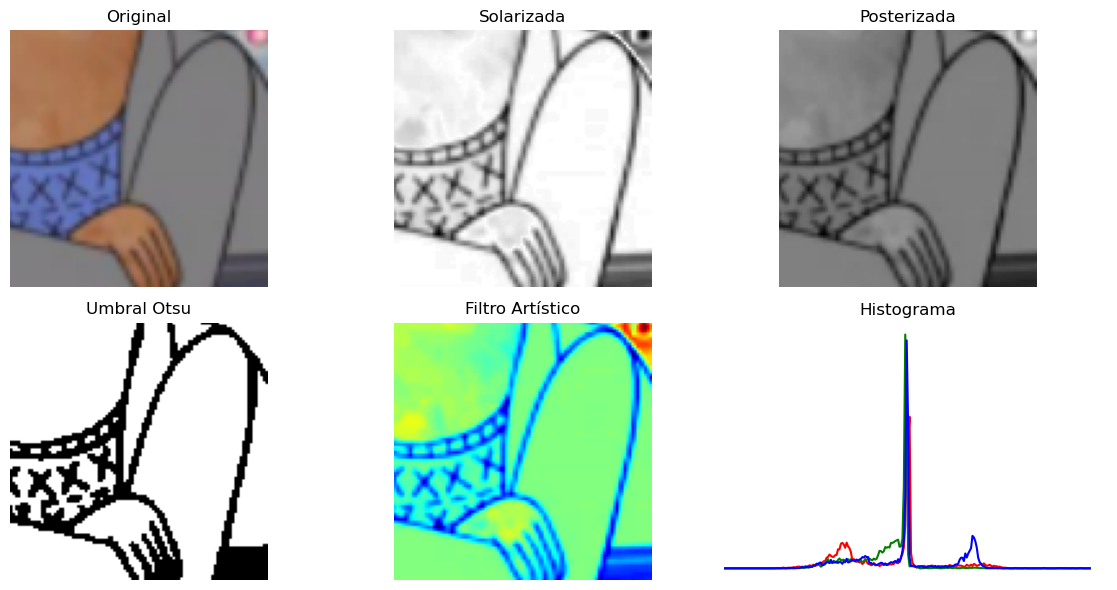

In [159]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración de tamaño de la figura
plt.rcParams['figure.figsize'] = [12, 6]

# Leer la imagen
imagen = cv2.imread("CABALLO.png")

# Dimensiones de la imagen
alto, ancho = imagen.shape[:2]

# Parámetros para recortar la imagen
lado = 100
desplazamiento_x = 50
desplazamiento_y = 50

centro_x = ancho // 2 + desplazamiento_x
centro_y = alto // 2 + desplazamiento_y

x1 = max(0, centro_x - lado // 2)
y1 = max(0, centro_y - lado // 2)
x2 = min(ancho, centro_x + lado // 2)
y2 = min(alto, centro_y + lado // 2)

# Recortar la imagen
imagen_recortada = imagen[y1:y2, x1:x2]

# Convertir a RGB
imagen_rgb = cv2.cvtColor(imagen_recortada, cv2.COLOR_BGR2RGB)

# Solarización
def solarizar(imagen, umbral):
    return np.where(imagen < umbral, imagen, 255 - imagen)

img_gris = cv2.cvtColor(imagen_recortada, cv2.COLOR_BGR2GRAY)
umbral = 127
img_solarizada = solarizar(img_gris, umbral)

# Posterización
def posterizada(imagen, nivel):
    factor = 255 / nivel
    img_post = np.round((imagen / factor) * factor)
    return img_post.astype(np.uint8)

nivel = 4
img_posterizada = posterizada(img_gris, nivel)

# Umbralización Otsu
imagen_gray = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
_, imagen_otsu = cv2.threshold(imagen_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Filtro artístico
imagen_gray_norm = cv2.normalize(imagen_gray, None, 0, 255, cv2.NORM_MINMAX)
img_colored = cv2.applyColorMap(imagen_gray_norm, 2)
img_colored = cv2.cvtColor(img_colored, cv2.COLOR_BGR2RGB)

# Crear un subplot con todas las imágenes
fig, axs = plt.subplots(2, 3)

# Imagen original recortada
axs[0, 0].imshow(imagen_rgb)
axs[0, 0].set_title("Original")
axs[0, 0].axis("off")

# Solarización
axs[0, 1].imshow(img_solarizada, cmap="gray")
axs[0, 1].set_title("Solarizada")
axs[0, 1].axis("off")

# Posterización
axs[0, 2].imshow(img_posterizada, cmap="gray")
axs[0, 2].set_title("Posterizada")
axs[0, 2].axis("off")

# Umbralización Otsu
axs[1, 0].imshow(imagen_otsu, cmap="gray")
axs[1, 0].set_title("Umbral Otsu")
axs[1, 0].axis("off")

# Filtro artístico
axs[1, 1].imshow(img_colored)
axs[1, 1].set_title("Filtro Artístico")
axs[1, 1].axis("off")

# Histograma por canales
color = ('r', 'g', 'b')
for canal, col in enumerate(color):
    histograma = cv2.calcHist([imagen_recortada], [canal], None, [256], [0, 256])
    axs[1, 2].plot(histograma, color=col)
axs[1, 2].set_title("Histograma")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()


Teoría:
¿A qué nos referimos si hablamos de una imagen digital?  
Res: Una imagen digital es una representación bidimensional de una imagen en formato digital, compuesta por una matriz de píxeles.
¿Qué es la profundidad del color?  
Res: se refiere al número de bits utilizados para representar el color de un solo píxel.

¿Cuál es la diferencia entre CMYK y RGB?  
Res: CMYK es un modelo de color sustractivo utilizado principalmente en impresión. En cambio RGB es un modelo de color, donde los colores se crean al combinar los tres colores primarios.